Plot saved. Scaling observed: Classical Time ~ N^3.32, GNN Time ~ N^1.88


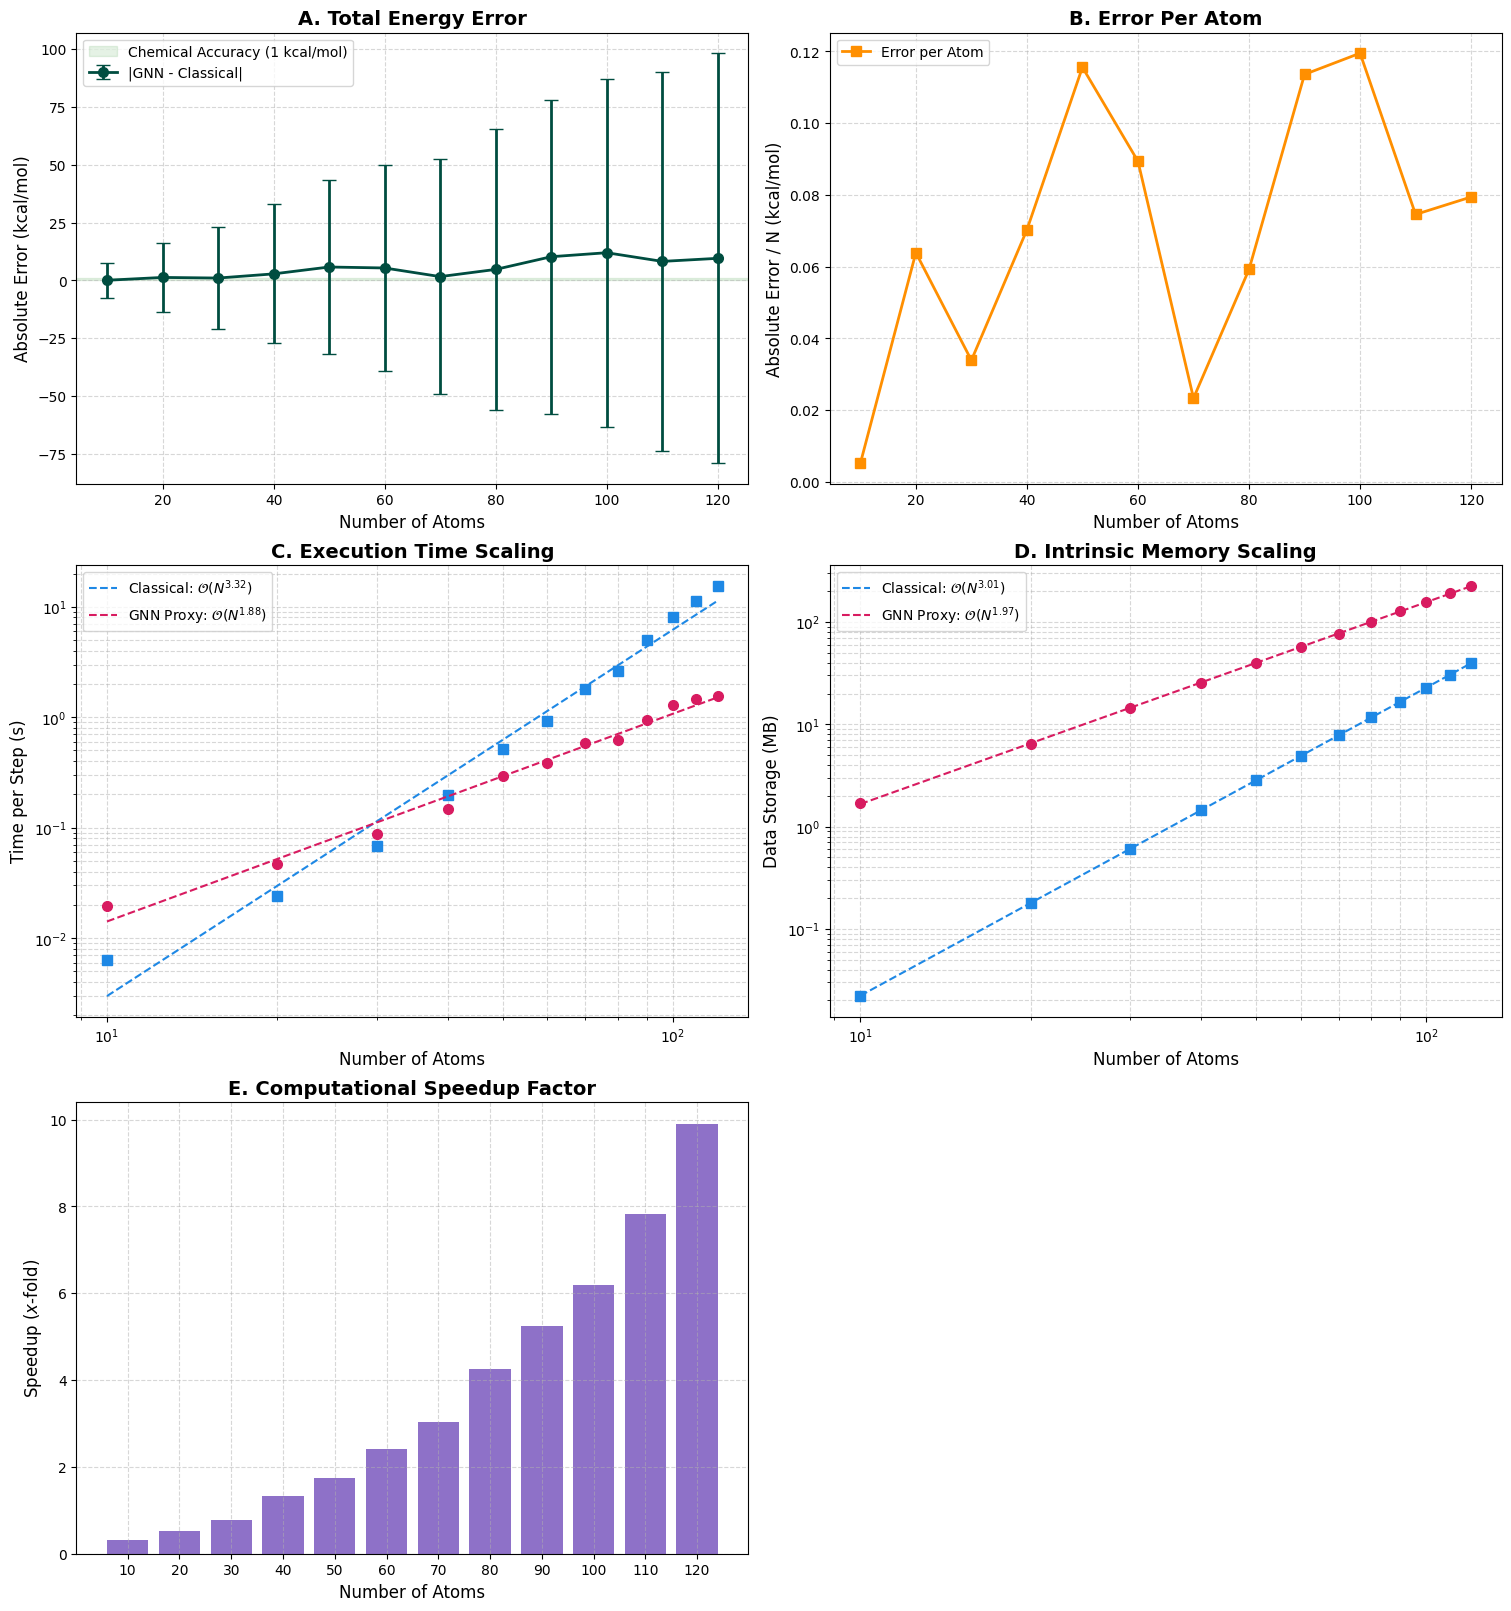

In [13]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. DATA EXTRACTION & FITTING UTILITIES
# =============================================================================
HA_TO_KCAL = 627.509

def power_law(x, a, b):
    return a * (x**b)

def get_scaling_exponent(x, y):
    """Fits y = a * x^b and returns (x_fit, y_fit, b)"""
    if len(x) < 2: return np.array([]), np.array([]), 0
    log_x, log_y = np.log(x), np.log(y)
    b, log_a = np.polyfit(log_x, log_y, 1)
    a = np.exp(log_a)
    x_fit = np.geomspace(min(x), max(x), 100)
    y_fit = power_law(x_fit, a, b)
    return x_fit, y_fit, b

data = []
dirs = glob.glob("../H_*_GNN")

for d in dirs:
    try:
        n_atoms = int(d.split('_')[1])
        gnn_file = os.path.join(d, f"scaling_metrics_GNN_H{n_atoms}.json")
        classical_file = os.path.join(d, f"scaling_metrics_Classical_H{n_atoms}.json")
        
        if os.path.exists(gnn_file) and os.path.exists(classical_file):
            with open(gnn_file, 'r') as f: gnn_m = json.load(f)
            with open(classical_file, 'r') as f: class_m = json.load(f)
            
            data.append({"N": n_atoms, "gnn": gnn_m, "classical": class_m})
    except Exception as e:
        print(f"Skipping {d}: {e}")

data = sorted(data, key=lambda x: x["N"])

# =============================================================================
# 2. DATA UNPACKING & ERROR PROPAGATION
# =============================================================================
N_vals = np.array([d["N"] for d in data])

def safe_extract(d, backend, key):
    proxy = d[backend].get("local_energy_proxy", {})
    val = proxy.get(key)
    if val is None and backend == "gnn" and key == "total_intrinsic_memory_mb":
        return proxy.get("model_weights_mb", 0.0) + proxy.get("graph_batch_mb", 0.0)
    return val if val is not None else 0.0

time_gnn = np.array([safe_extract(d, "gnn", "avg_time_sec") for d in data])
time_class = np.array([safe_extract(d, "classical", "avg_time_sec") for d in data])

mem_gnn = np.array([safe_extract(d, "gnn", "total_intrinsic_memory_mb") for d in data])
mem_class = np.array([safe_extract(d, "classical", "total_intrinsic_memory_mb") for d in data])

# Extract energies
e_gnn = np.array([d["gnn"]["results"].get("final_energy_ha", 0) for d in data])
e_class = np.array([d["classical"]["results"].get("final_energy_ha", 0) for d in data])

# Extract statistical errors (defaulting to 0 if not present to avoid breaking)
err_gnn = np.array([d["gnn"]["results"].get("final_error_ha", 0) for d in data])
err_class = np.array([d["classical"]["results"].get("final_error_ha", 0) for d in data])

# Calculate absolute difference and propagate error (converted to kcal/mol)
energy_diff_kcal = np.abs(e_gnn - e_class) * HA_TO_KCAL
energy_err_kcal = np.sqrt(err_gnn**2 + err_class**2) * HA_TO_KCAL

# Calculate per-atom metrics
error_per_atom_kcal = energy_diff_kcal / N_vals
err_per_atom_bars_kcal = energy_err_kcal / N_vals

# =============================================================================
# 3. PLOTTING (Updated 3x2 Grid)
# =============================================================================
fig, axs = plt.subplots(3, 2, figsize=(15, 16), constrained_layout=True)
c_gnn, c_class = '#D81B60', '#1E88E5'
lw, ms, cap = 2.0, 7, 5

# --- Panel A: Total Energy Accuracy with Error Bars ---
axs[0, 0].errorbar(N_vals, energy_diff_kcal, yerr=energy_err_kcal, fmt='-o', 
                   color='#004D40', lw=lw, ms=ms, capsize=cap, label='|GNN - Classical|')
axs[0, 0].axhspan(0, 1.0, color='green', alpha=0.1, label='Chemical Accuracy (1 kcal/mol)')
axs[0, 0].set_title('A. Total Energy Error', fontsize=14, fontweight='bold')
axs[0, 0].set_ylabel('Absolute Error (kcal/mol)', fontsize=12)
axs[0, 0].legend()

# --- Panel B: Error Per Atom with Error Bars ---
axs[0, 1].errorbar(N_vals, error_per_atom_kcal, yerr=err_per_atom_bars_kcal, fmt='-s', 
                   color='#FF8F00', lw=lw, ms=ms, capsize=cap, label='Error per Atom')
axs[0, 1].set_title('B. Error Per Atom', fontsize=14, fontweight='bold')
axs[0, 1].set_ylabel('Absolute Error / N (kcal/mol)', fontsize=12)
axs[0, 1].legend()

# --- Panel C: Time Scaling (Log-Log) ---
xf, yf, b_c = get_scaling_exponent(N_vals, time_class)
axs[1, 0].plot(N_vals, time_class, 's', color=c_class, ms=ms)
axs[1, 0].plot(xf, yf, '--', color=c_class, label=f'Classical: $\mathcal{{O}}(N^{{{b_c:.2f}}})$')

xf, yf, b_g = get_scaling_exponent(N_vals, time_gnn)
axs[1, 0].plot(N_vals, time_gnn, 'o', color=c_gnn, ms=ms)
axs[1, 0].plot(xf, yf, '--', color=c_gnn, label=f'GNN Proxy: $\mathcal{{O}}(N^{{{b_g:.2f}}})$')

axs[1, 0].set_xscale('log')
axs[1, 0].set_yscale('log')
axs[1, 0].set_title('C. Execution Time Scaling', fontsize=14, fontweight='bold')
axs[1, 0].set_ylabel('Time per Step (s)', fontsize=12)
axs[1, 0].legend()

# --- Panel D: Memory Scaling (Log-Log) ---
xf, yf, b_mc = get_scaling_exponent(N_vals, mem_class)
axs[1, 1].plot(N_vals, mem_class, 's', color=c_class, ms=ms)
axs[1, 1].plot(xf, yf, '--', color=c_class, label=f'Classical: $\mathcal{{O}}(N^{{{b_mc:.2f}}})$')

xf, yf, b_mg = get_scaling_exponent(N_vals, mem_gnn)
axs[1, 1].plot(N_vals, mem_gnn, 'o', color=c_gnn, ms=ms)
axs[1, 1].plot(xf, yf, '--', color=c_gnn, label=f'GNN Proxy: $\mathcal{{O}}(N^{{{b_mg:.2f}}})$')

axs[1, 1].set_xscale('log')
axs[1, 1].set_yscale('log')
axs[1, 1].set_title('D. Intrinsic Memory Scaling', fontsize=14, fontweight='bold')
axs[1, 1].set_ylabel('Data Storage (MB)', fontsize=12)
axs[1, 1].legend()

# --- Panel E: Relative Speedup (Classical Time / GNN Time) ---
speedup = time_class / time_gnn
axs[2, 0].bar(N_vals.astype(str), speedup, color='#5E35B1', alpha=0.7)
axs[2, 0].set_title('E. Computational Speedup Factor', fontsize=14, fontweight='bold')
axs[2, 0].set_ylabel('Speedup ($x$-fold)', fontsize=12)
axs[2, 0].set_xlabel('Number of Atoms', fontsize=12)

# Hide the empty 6th subplot
axs[2, 1].axis('off')

# Format grids and x-labels for all active plots
for i, ax in enumerate(axs.flat): 
    if i != 5:  # Skip the empty plot
        ax.grid(True, which="both", ls="--", alpha=0.5)
        if i < 4: ax.set_xlabel('Number of Atoms', fontsize=12)

plt.savefig("AFQMC_Scaling_Analysis.png", dpi=300)
print(f"Plot saved. Scaling observed: Classical Time ~ N^{b_c:.2f}, GNN Time ~ N^{b_g:.2f}")

Plot saved. Scaling observed: Classical Time ~ N^3.35, GNN Time ~ N^1.90


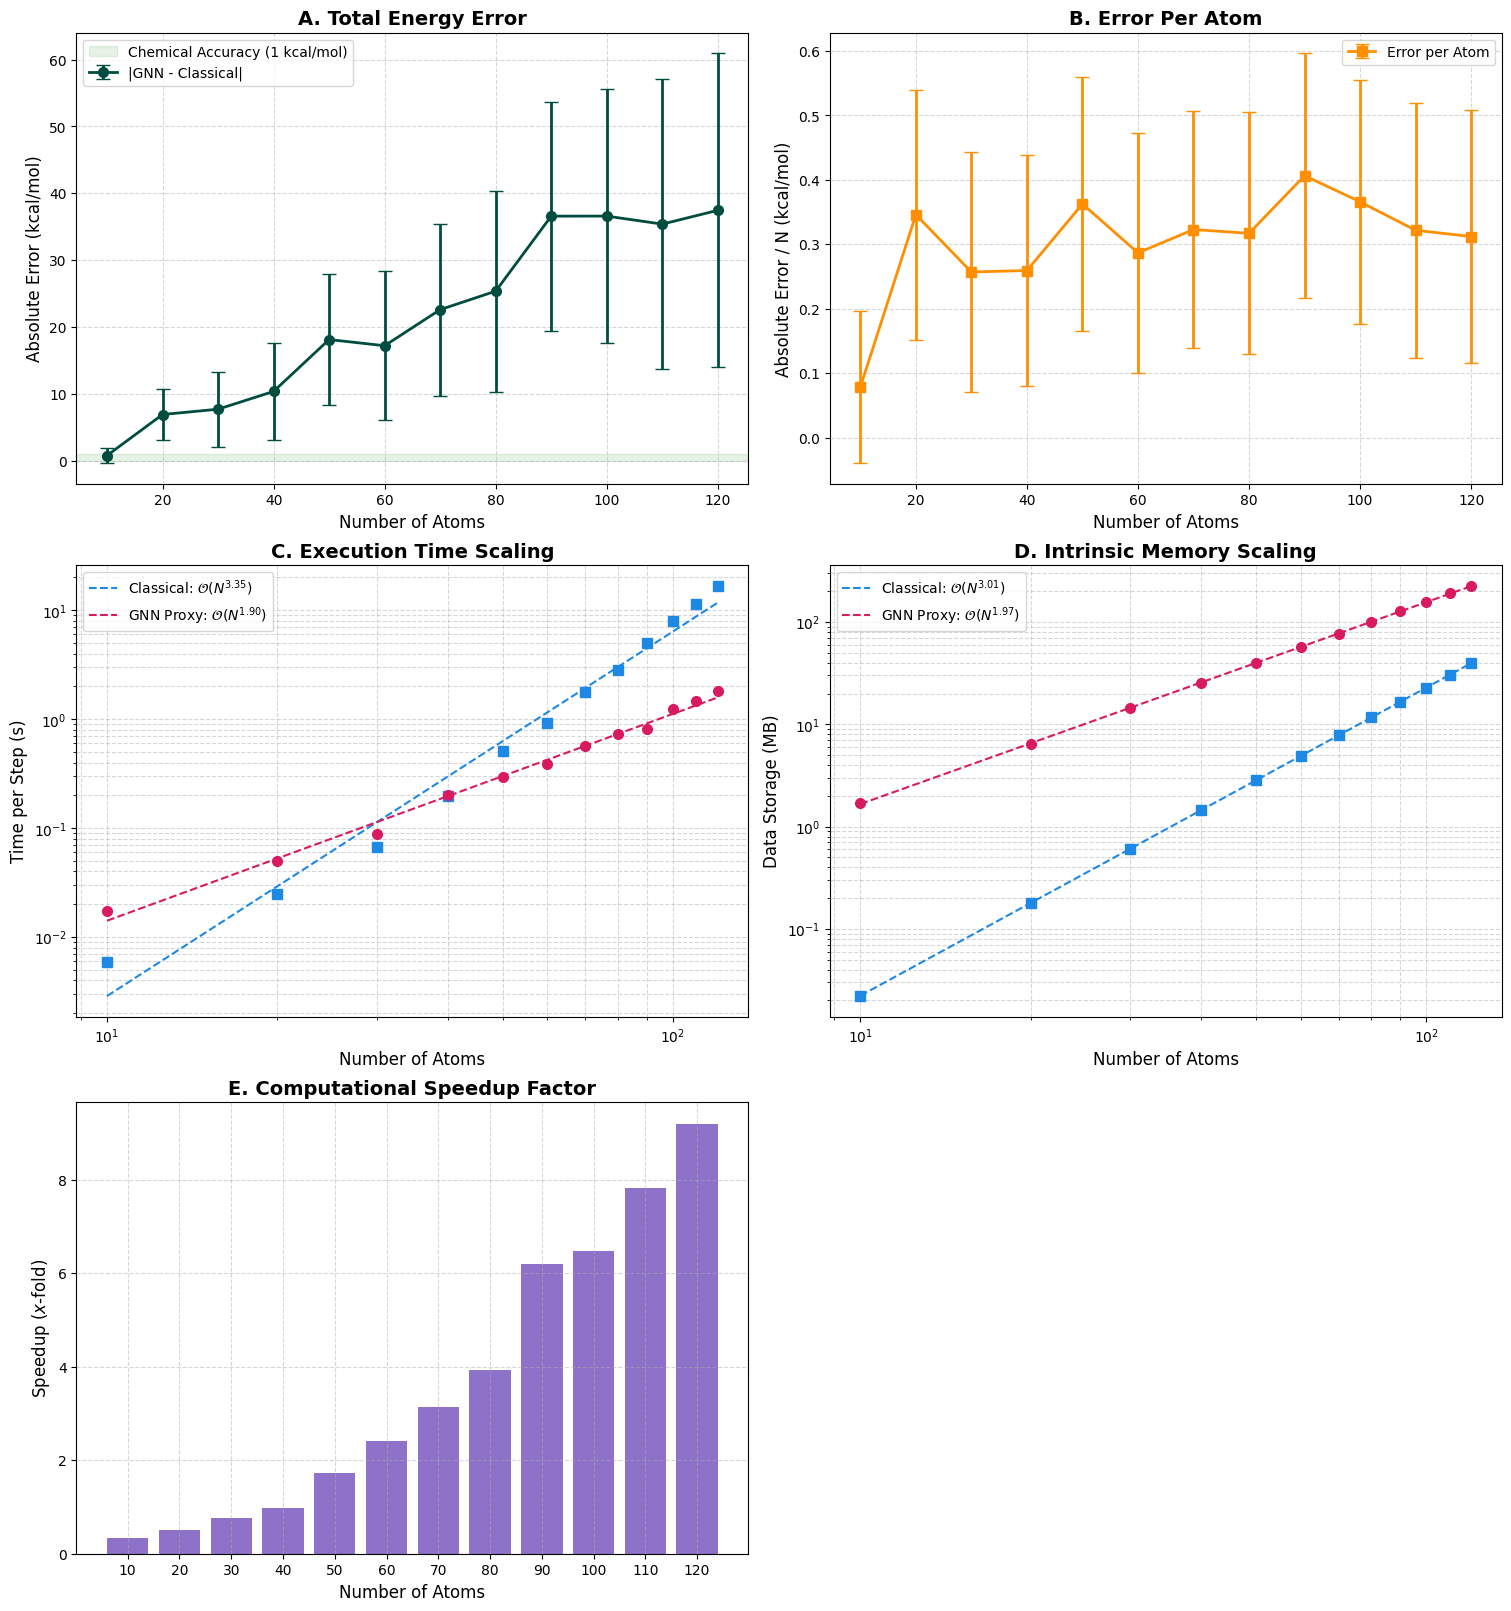

In [3]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. DATA EXTRACTION & FITTING UTILITIES
# =============================================================================
HA_TO_KCAL = 627.509

def power_law(x, a, b):
    return a * (x**b)

def get_scaling_exponent(x, y):
    """Fits y = a * x^b and returns (x_fit, y_fit, b)"""
    if len(x) < 2: return np.array([]), np.array([]), 0
    log_x, log_y = np.log(x), np.log(y)
    b, log_a = np.polyfit(log_x, log_y, 1)
    a = np.exp(log_a)
    x_fit = np.geomspace(min(x), max(x), 100)
    y_fit = power_law(x_fit, a, b)
    return x_fit, y_fit, b

data = []
dirs = glob.glob("../H_*_GNN-MB")

for d in dirs:
    try:
        n_atoms = int(d.split('_')[1])
        gnn_file = os.path.join(d, f"scaling_metrics_GNN_H{n_atoms}.json")
        classical_file = os.path.join(d, f"scaling_metrics_Classical_H{n_atoms}.json")
        
        if os.path.exists(gnn_file) and os.path.exists(classical_file):
            with open(gnn_file, 'r') as f: gnn_m = json.load(f)
            with open(classical_file, 'r') as f: class_m = json.load(f)
            
            data.append({"N": n_atoms, "gnn": gnn_m, "classical": class_m})
    except Exception as e:
        print(f"Skipping {d}: {e}")

data = sorted(data, key=lambda x: x["N"])

# =============================================================================
# 2. DATA UNPACKING & ERROR PROPAGATION
# =============================================================================
N_vals = np.array([d["N"] for d in data])

def safe_extract(d, backend, key):
    proxy = d[backend].get("local_energy_proxy", {})
    val = proxy.get(key)
    if val is None and backend == "gnn" and key == "total_intrinsic_memory_mb":
        return proxy.get("model_weights_mb", 0.0) + proxy.get("graph_batch_mb", 0.0)
    return val if val is not None else 0.0

time_gnn = np.array([safe_extract(d, "gnn", "avg_time_sec") for d in data])
time_class = np.array([safe_extract(d, "classical", "avg_time_sec") for d in data])

mem_gnn = np.array([safe_extract(d, "gnn", "total_intrinsic_memory_mb") for d in data])
mem_class = np.array([safe_extract(d, "classical", "total_intrinsic_memory_mb") for d in data])

# Extract energies
e_gnn = np.array([d["gnn"]["results"].get("final_energy_ha", 0) for d in data])
e_class = np.array([d["classical"]["results"].get("final_energy_ha", 0) for d in data])

# Extract statistical errors (defaulting to 0 if not present to avoid breaking)
err_gnn = np.array([d["gnn"]["results"].get("final_error_ha", 0) for d in data])
err_class = np.array([d["classical"]["results"].get("final_error_ha", 0) for d in data])

# Calculate absolute difference and propagate error (converted to kcal/mol)
energy_diff_kcal = np.abs(e_gnn - e_class) * HA_TO_KCAL
energy_err_kcal = np.sqrt(err_gnn**2 + err_class**2) * HA_TO_KCAL

# Calculate per-atom metrics
error_per_atom_kcal = energy_diff_kcal / N_vals
err_per_atom_bars_kcal = energy_err_kcal / N_vals

# =============================================================================
# 3. PLOTTING (Updated 3x2 Grid)
# =============================================================================
fig, axs = plt.subplots(3, 2, figsize=(15, 16), constrained_layout=True)
c_gnn, c_class = '#D81B60', '#1E88E5'
lw, ms, cap = 2.0, 7, 5

# --- Panel A: Total Energy Accuracy with Error Bars ---
axs[0, 0].errorbar(N_vals, energy_diff_kcal, yerr=energy_err_kcal, fmt='-o', 
                   color='#004D40', lw=lw, ms=ms, capsize=cap, label='|GNN - Classical|')
axs[0, 0].axhspan(0, 1.0, color='green', alpha=0.1, label='Chemical Accuracy (1 kcal/mol)')
axs[0, 0].set_title('A. Total Energy Error', fontsize=14, fontweight='bold')
axs[0, 0].set_ylabel('Absolute Error (kcal/mol)', fontsize=12)
axs[0, 0].legend()

# --- Panel B: Error Per Atom with Error Bars ---
axs[0, 1].errorbar(N_vals, error_per_atom_kcal, yerr=err_per_atom_bars_kcal, fmt='-s', 
                   color='#FF8F00', lw=lw, ms=ms, capsize=cap, label='Error per Atom')
axs[0, 1].set_title('B. Error Per Atom', fontsize=14, fontweight='bold')
axs[0, 1].set_ylabel('Absolute Error / N (kcal/mol)', fontsize=12)
axs[0, 1].legend()

# --- Panel C: Time Scaling (Log-Log) ---
xf, yf, b_c = get_scaling_exponent(N_vals, time_class)
axs[1, 0].plot(N_vals, time_class, 's', color=c_class, ms=ms)
axs[1, 0].plot(xf, yf, '--', color=c_class, label=f'Classical: $\mathcal{{O}}(N^{{{b_c:.2f}}})$')

xf, yf, b_g = get_scaling_exponent(N_vals, time_gnn)
axs[1, 0].plot(N_vals, time_gnn, 'o', color=c_gnn, ms=ms)
axs[1, 0].plot(xf, yf, '--', color=c_gnn, label=f'GNN Proxy: $\mathcal{{O}}(N^{{{b_g:.2f}}})$')

axs[1, 0].set_xscale('log')
axs[1, 0].set_yscale('log')
axs[1, 0].set_title('C. Execution Time Scaling', fontsize=14, fontweight='bold')
axs[1, 0].set_ylabel('Time per Step (s)', fontsize=12)
axs[1, 0].legend()

# --- Panel D: Memory Scaling (Log-Log) ---
xf, yf, b_mc = get_scaling_exponent(N_vals, mem_class)
axs[1, 1].plot(N_vals, mem_class, 's', color=c_class, ms=ms)
axs[1, 1].plot(xf, yf, '--', color=c_class, label=f'Classical: $\mathcal{{O}}(N^{{{b_mc:.2f}}})$')

xf, yf, b_mg = get_scaling_exponent(N_vals, mem_gnn)
axs[1, 1].plot(N_vals, mem_gnn, 'o', color=c_gnn, ms=ms)
axs[1, 1].plot(xf, yf, '--', color=c_gnn, label=f'GNN Proxy: $\mathcal{{O}}(N^{{{b_mg:.2f}}})$')

axs[1, 1].set_xscale('log')
axs[1, 1].set_yscale('log')
axs[1, 1].set_title('D. Intrinsic Memory Scaling', fontsize=14, fontweight='bold')
axs[1, 1].set_ylabel('Data Storage (MB)', fontsize=12)
axs[1, 1].legend()

# --- Panel E: Relative Speedup (Classical Time / GNN Time) ---
speedup = time_class / time_gnn
axs[2, 0].bar(N_vals.astype(str), speedup, color='#5E35B1', alpha=0.7)
axs[2, 0].set_title('E. Computational Speedup Factor', fontsize=14, fontweight='bold')
axs[2, 0].set_ylabel('Speedup ($x$-fold)', fontsize=12)
axs[2, 0].set_xlabel('Number of Atoms', fontsize=12)

# Hide the empty 6th subplot
axs[2, 1].axis('off')

# Format grids and x-labels for all active plots
for i, ax in enumerate(axs.flat): 
    if i != 5:  # Skip the empty plot
        ax.grid(True, which="both", ls="--", alpha=0.5)
        if i < 4: ax.set_xlabel('Number of Atoms', fontsize=12)

plt.savefig("AFQMC_Scaling_Analysis.png", dpi=300)
print(f"Plot saved. Scaling observed: Classical Time ~ N^{b_c:.2f}, GNN Time ~ N^{b_g:.2f}")

In [1]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from ipie.analysis.autocorr import reblock_by_autocorr

# =============================================================================
# 1. DATA EXTRACTION & FITTING UTILITIES
# =============================================================================
HA_TO_KCAL = 627.509

def power_law(x, a, b):
    return a * (x**b)

def get_scaling_exponent(x, y):
    """Fits y = a * x^b and returns (x_fit, y_fit, b)"""
    if len(x) < 2: return np.array([]), np.array([]), 0
    log_x, log_y = np.log(x), np.log(y)
    b, log_a = np.polyfit(log_x, log_y, 1)
    a = np.exp(log_a)
    x_fit = np.geomspace(min(x), max(x), 100)
    y_fit = power_law(x_fit, a, b)
    return x_fit, y_fit, b

data = []
dirs = glob.glob("../H_*_GNN")

for d in dirs:
    try:
        n_atoms = int(d.split('_')[1])
        gnn_file = os.path.join(d, f"scaling_metrics_GNN_H{n_atoms}.json")
        classical_file = os.path.join(d, f"scaling_metrics_Classical_H{n_atoms}.json")
        
        if os.path.exists(gnn_file) and os.path.exists(classical_file):
            with open(gnn_file, 'r') as f: gnn_m = json.load(f)
            with open(classical_file, 'r') as f: class_m = json.load(f)
            
            data.append({"N": n_atoms, "gnn": gnn_m, "classical": class_m})
    except Exception as e:
        print(f"Skipping {d}: {e}")

data = sorted(data, key=lambda x: x["N"])

# =============================================================================
# 2. DATA UNPACKING & RIGOROUS ERROR PROPAGATION
# =============================================================================
N_vals = np.array([d["N"] for d in data])

def safe_extract(d, backend, key):
    proxy = d[backend].get("local_energy_proxy", {})
    val = proxy.get(key)
    if val is None and backend == "gnn" and key == "total_intrinsic_memory_mb":
        return proxy.get("model_weights_mb", 0.0) + proxy.get("graph_batch_mb", 0.0)
    return val if val is not None else 0.0

time_gnn = np.array([safe_extract(d, "gnn", "avg_time_sec") for d in data])
time_class = np.array([safe_extract(d, "classical", "avg_time_sec") for d in data])

mem_gnn = np.array([safe_extract(d, "gnn", "total_intrinsic_memory_mb") for d in data])
mem_class = np.array([safe_extract(d, "classical", "total_intrinsic_memory_mb") for d in data])

# --- NEW: Rigorous Block-by-Block Error Calculation ---
energy_diff_kcal_list = []
energy_err_kcal_list = []

for d in data:
    # 1. Extract raw blocks
    raw_gnn = np.array(d["gnn"]["results"]["raw_block_energies"])
    raw_class = np.array(d["classical"]["results"]["raw_block_energies"])
    
    # 2. Compute the exact block-by-block difference
    e_diff = (raw_gnn - raw_class).flatten()
    
    # 3. Reblock the difference array to get correlated errors
    try:
        df_diff_ac = reblock_by_autocorr(e_diff, name="E_Diff", verbose=0)
    except TypeError:
        df_diff_ac = reblock_by_autocorr(e_diff, verbose=0)
        
    mean_diff_ha = float(df_diff_ac.iloc[0, 0])
    error_diff_ha = float(df_diff_ac.iloc[0, 1])
    
    # 4. Store absolute difference (for log/absolute plots) and propagated error
    energy_diff_kcal_list.append(np.abs(mean_diff_ha) * HA_TO_KCAL)
    energy_err_kcal_list.append(error_diff_ha * HA_TO_KCAL)

energy_diff_kcal = np.array(energy_diff_kcal_list)
energy_err_kcal = np.array(energy_err_kcal_list)

# Calculate per-atom metrics
error_per_atom_kcal = energy_diff_kcal / N_vals
err_per_atom_bars_kcal = energy_err_kcal / N_vals

# =============================================================================
# 3. PLOTTING (Updated 3x2 Grid)
# =============================================================================
fig, axs = plt.subplots(3, 2, figsize=(15, 16), constrained_layout=True)
c_gnn, c_class = '#D81B60', '#1E88E5'
lw, ms, cap = 2.0, 7, 5

# --- Panel A: Total Energy Accuracy with Error Bars ---
axs[0, 0].errorbar(N_vals, energy_diff_kcal, yerr=energy_err_kcal, fmt='-o', 
                   color='#004D40', lw=lw, ms=ms, capsize=cap, label='|GNN - Classical|')
axs[0, 0].axhspan(0, 1.0, color='green', alpha=0.1, label='Chemical Accuracy (1 kcal/mol)')
axs[0, 0].set_title('A. Total Energy Error', fontsize=14, fontweight='bold')
axs[0, 0].set_ylabel('Absolute Error (kcal/mol)', fontsize=12)
axs[0, 0].legend()

# --- Panel B: Error Per Atom with Error Bars ---
axs[0, 1].errorbar(N_vals, error_per_atom_kcal, yerr=err_per_atom_bars_kcal, fmt='-s', 
                   color='#FF8F00', lw=lw, ms=ms, capsize=cap, label='Error per Atom')
axs[0, 1].set_title('B. Error Per Atom', fontsize=14, fontweight='bold')
axs[0, 1].set_ylabel('Absolute Error / N (kcal/mol)', fontsize=12)
axs[0, 1].legend()

# --- Panel C: Time Scaling (Log-Log) ---
xf, yf, b_c = get_scaling_exponent(N_vals, time_class)
axs[1, 0].plot(N_vals, time_class, 's', color=c_class, ms=ms)
axs[1, 0].plot(xf, yf, '--', color=c_class, label=f'Classical: $\mathcal{{O}}(N^{{{b_c:.2f}}})$')

xf, yf, b_g = get_scaling_exponent(N_vals, time_gnn)
axs[1, 0].plot(N_vals, time_gnn, 'o', color=c_gnn, ms=ms)
axs[1, 0].plot(xf, yf, '--', color=c_gnn, label=f'GNN Proxy: $\mathcal{{O}}(N^{{{b_g:.2f}}})$')

axs[1, 0].set_xscale('log')
axs[1, 0].set_yscale('log')
axs[1, 0].set_title('C. Execution Time Scaling', fontsize=14, fontweight='bold')
axs[1, 0].set_ylabel('Time per Step (s)', fontsize=12)
axs[1, 0].legend()

# --- Panel D: Memory Scaling (Log-Log) ---
xf, yf, b_mc = get_scaling_exponent(N_vals, mem_class)
axs[1, 1].plot(N_vals, mem_class, 's', color=c_class, ms=ms)
axs[1, 1].plot(xf, yf, '--', color=c_class, label=f'Classical: $\mathcal{{O}}(N^{{{b_mc:.2f}}})$')

xf, yf, b_mg = get_scaling_exponent(N_vals, mem_gnn)
axs[1, 1].plot(N_vals, mem_gnn, 'o', color=c_gnn, ms=ms)
axs[1, 1].plot(xf, yf, '--', color=c_gnn, label=f'GNN Proxy: $\mathcal{{O}}(N^{{{b_mg:.2f}}})$')

axs[1, 1].set_xscale('log')
axs[1, 1].set_yscale('log')
axs[1, 1].set_title('D. Intrinsic Memory Scaling', fontsize=14, fontweight='bold')
axs[1, 1].set_ylabel('Data Storage (MB)', fontsize=12)
axs[1, 1].legend()

# --- Panel E: Relative Speedup (Classical Time / GNN Time) ---
speedup = time_class / time_gnn
axs[2, 0].bar(N_vals.astype(str), speedup, color='#5E35B1', alpha=0.7)
axs[2, 0].set_title('E. Computational Speedup Factor', fontsize=14, fontweight='bold')
axs[2, 0].set_ylabel('Speedup ($x$-fold)', fontsize=12)
axs[2, 0].set_xlabel('Number of Atoms', fontsize=12)

# Hide the empty 6th subplot
axs[2, 1].axis('off')

# Format grids and x-labels for all active plots
for i, ax in enumerate(axs.flat): 
    if i != 5:  # Skip the empty plot
        ax.grid(True, which="both", ls="--", alpha=0.5)
        if i < 4: ax.set_xlabel('Number of Atoms', fontsize=12)

plt.savefig("AFQMC_Scaling_Analysis.png", dpi=300)
print(f"Plot saved. Scaling observed: Classical Time ~ N^{b_c:.2f}, GNN Time ~ N^{b_g:.2f}")

KeyError: 'raw_block_energies'